In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# **a. Load Dataset 'cancer_coded.csv'**

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cancer_coded.csv')
dataset

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,0
679,841769,2,1,1,1,2,1,1,1,1,0
680,888820,5,10,10,3,7,3,8,10,2,1
681,897471,4,8,6,4,3,4,10,6,1,1


# **b. You need to drop the 'Sample code number' from the dataset as this does not contribute to the prediction (data cleaning)**

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cancer_coded.csv', encoding='ISO-8859-1')
dataset = dataset.drop('Sample code number', axis=1)
dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,0
679,2,1,1,1,2,1,1,1,1,0
680,5,10,10,3,7,3,8,10,2,1
681,4,8,6,4,3,4,10,6,1,1


# **c. Insert a validation data at the end of the dataframe [5, 9, 9, 3, 7, 3, 8, 9, 2, -1], [3, 2, 1, 1, 2, 3, 1, 1, 1, -1]**

In [ ]:
# Add the new rows
new_rows = np.array([[5, 9, 9, 3, 7, 3, 8, 9, 2, -1], [3, 2, 1, 1, 2, 3, 1, 1, 1, -1]])
new_rows_df = pd.DataFrame(new_rows, columns=dataset.columns)
dataset = pd.concat([dataset, new_rows_df], ignore_index=True)

# Display the updated dataset (optional)
dataset

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
680,5,10,10,3,7,3,8,10,2,1
681,4,8,6,4,3,4,10,6,1,1
682,4,8,8,5,4,5,10,4,1,1
683,5,9,9,3,7,3,8,9,2,-1


# **d. Use StandardScaler to normalize the dataset**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize StandardScaler
scaler = StandardScaler()

# Select the columns to be scaled (excluding 'Class')
columns_to_scale = dataset.columns.drop('Class')
dataset_to_scale = dataset[columns_to_scale]

# Fit the scaler to the selected columns and transform the data
dataset_scaled_values = scaler.fit_transform(dataset_to_scale)

# Convert the scaled data back to a pandas DataFrame with appropriate column names
dataset_scaled_df = pd.DataFrame(dataset_scaled_values, columns=columns_to_scale)

# Add the 'Class' column back to the scaled DataFrame
dataset_scaled_df['Class'] = dataset['Class']

# Display the rows of the scaled dataset
dataset_scaled_df

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,0.198609,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
1,0.198609,0.274655,0.260601,0.759760,1.692045,1.775840,-0.182758,-0.286640,-0.348691,0
2,-0.511821,-0.703536,-0.742273,-0.639260,-0.556793,-0.424387,-0.182758,-0.613887,-0.348691,0
3,0.553824,1.578909,1.597766,-0.639260,-0.107025,0.125670,-0.182758,1.349595,-0.348691,0
4,-0.156606,-0.703536,-0.742273,0.060250,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
...,...,...,...,...,...,...,...,...,...,...
680,0.198609,2.231036,2.266349,0.060250,1.692045,-0.149358,1.856151,2.331336,0.229646,1
681,-0.156606,1.578909,0.929184,0.410005,-0.107025,0.125670,2.671714,1.022348,-0.348691,1
682,-0.156606,1.578909,1.597766,0.759760,0.342743,0.400698,2.671714,0.367854,-0.348691,1
683,0.198609,1.904972,1.932058,0.060250,1.692045,-0.149358,1.856151,2.004089,0.229646,-1


# **e. Remove the validation data from the dataset before training**

In [ ]:
dataset_scaled_df = dataset_scaled_df[:-2]
dataset_scaled_df

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,0.198609,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
1,0.198609,0.274655,0.260601,0.759760,1.692045,1.775840,-0.182758,-0.286640,-0.348691,0
2,-0.511821,-0.703536,-0.742273,-0.639260,-0.556793,-0.424387,-0.182758,-0.613887,-0.348691,0
3,0.553824,1.578909,1.597766,-0.639260,-0.107025,0.125670,-0.182758,1.349595,-0.348691,0
4,-0.156606,-0.703536,-0.742273,0.060250,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691,0
...,...,...,...,...,...,...,...,...,...,...
678,-0.511821,-0.703536,-0.742273,-0.639260,-0.107025,-0.424387,-0.998321,-0.613887,-0.348691,0
679,-0.867035,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.998321,-0.613887,-0.348691,0
680,0.198609,2.231036,2.266349,0.060250,1.692045,-0.149358,1.856151,2.331336,0.229646,1
681,-0.156606,1.578909,0.929184,0.410005,-0.107025,0.125670,2.671714,1.022348,-0.348691,1


# **f. Train/Test Split is test_size = 0.2, random_state = 101**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = dataset_scaled_df.drop('Class', axis = 1)
y = dataset_scaled_df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [ ]:
X_test

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
660,-1.222250,-0.703536,-0.407982,-0.639260,-0.556793,-0.699415,-0.590539,-0.613887,-0.348691
597,1.264254,2.231036,2.266349,2.508535,1.242278,1.775840,2.671714,2.331336,4.856342
494,-0.867035,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.998321,-0.613887,-0.348691
139,1.619469,0.600718,0.594892,0.410005,0.342743,0.400698,0.225024,0.040607,0.807983
399,1.264254,0.600718,0.929184,-0.289505,-0.107025,1.775840,1.040588,1.022348,-0.348691
...,...,...,...,...,...,...,...,...,...
627,-1.222250,-0.703536,-0.742273,-0.639260,-0.556793,-0.699415,-0.998321,-0.613887,-0.348691
664,1.974684,2.231036,2.266349,2.508535,0.792510,1.775840,2.671714,2.331336,3.121331
80,0.198609,-0.377472,-0.742273,-0.639260,-0.556793,-0.699415,-0.182758,-0.613887,-0.348691
98,1.974684,-0.051409,0.594892,-0.639260,3.041348,0.400698,-0.182758,2.331336,0.229646


In [ ]:
y_train

,Class
320,1
411,0
111,1
307,1
8,0
...,...
75,0
599,0
575,1
337,0


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state = 101)
model.fit(X_train, y_train)

LogisticRegression(random_state=101)

# **Proving of answers (1-5)**

In [ ]:
prediction = model.predict(X_test)
prediction

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0])

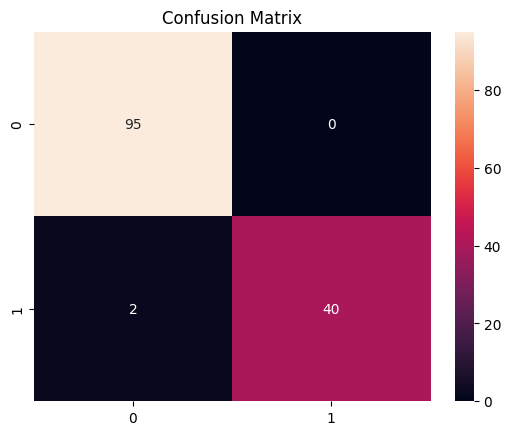

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix

cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot = True, fmt = "d", xticklabels = ['0', '1'], yticklabels = ['0', '1']).set(title = 'Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        95
           1       1.00      0.95      0.98        42

    accuracy                           0.99       137
   macro avg       0.99      0.98      0.98       137
weighted avg       0.99      0.99      0.99       137



In [ ]:
validation_data1 = dataset.iloc[-2].drop('Class').values.reshape(1, -1)
validation_data1_scaled = scaler.transform(validation_data1)

# Make the prediction
prediction_on_validation1 = model.predict(validation_data1_scaled)

print(f"The prediction for 1st validation data is: {prediction_on_validation1[0]}")

The prediction for 1st validation data is: 1


In [ ]:
validation_data2 = dataset.iloc[-1].drop('Class').values.reshape(1, -1)
validation_data2_scaled = scaler.transform(validation_data2)

# Make the prediction
sec_prediction_on_validation2 = model.predict(validation_data2_scaled)

print(f"The prediction for 2nd validation data is: {sec_prediction_on_validation2[0]}")

The prediction for 2nd validation data is: 0


In [ ]:
# Get the coefficients of the trained model
coefficients = model.coef_[0]

# Pair the coefficients with the corresponding column names
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})

# Sort the features by the absolute value of their coefficients
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Display the features and their coefficients
print("Feature Importance (based on absolute coefficient values):")
feature_importance

Feature Importance (based on absolute coefficient values):


,Feature,Coefficient,Abs_Coefficient
0,Clump Thickness,1.213264,1.213264
5,Bare Nuclei,1.076227,1.076227
6,Bland Chromatin,0.970864,0.970864
3,Marginal Adhesion,0.811777,0.811777
8,Mitoses,0.722668,0.722668
2,Uniformity of Cell Shape,0.637292,0.637292
7,Normal Nucleoli,0.450180,0.450180
1,Uniformity of Cell Size,0.367803,0.367803
4,Single Epithelial Cell Size,0.275540,0.275540
